# BUILD A LARGE LANGUAGE MODEL FROM SCRATCH

In [1]:
# ── Device setup (GPU) ──────────────────────────────────────────────
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", device)
if device.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))


PyTorch: 2.4.1+cu124
Device : cuda
GPU    : NVIDIA GeForce RTX 4090


### STEP 1: LOADING THE DATASET


In [7]:
import os

file_path = "A History of Indian Philosophy Volume 1.txt"

# Check if the file exists in the current directory (i.e., Colab session)
if os.path.exists(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        raw_text = file.read()
    print(f"File '{file_path}' loaded with {len(raw_text)} characters.")
else:
    print(f"File '{file_path}' not found. Please upload it to the Colab environment first.")


File 'A History of Indian Philosophy Volume 1.txt' loaded with 1342083 characters.


### STEP 2: IMPLEMENTING THE TOKENIZER


In [8]:
!pip3 install tiktoken > /dev/null 2>&1

In [9]:
import importlib
import tiktoken

print("tiktoken version:", importlib.metadata.version("tiktoken"))

tiktoken version: 0.12.0


In [10]:
tokenizer = tiktoken.get_encoding("gpt2")

In [11]:
total_characters = len(raw_text)
total_tokens = len(tokenizer.encode(raw_text))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 1342083
Tokens: 357340


### STEP 3: CREATING INPUT-TARGET PAIRS

In [12]:
with open("A History of Indian Philosophy Volume 1.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

357340


In [13]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [14]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [15]:
import torch
print("PyTorch version:", torch.__version__)
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

PyTorch version: 2.4.1+cu124
[tensor([[  464,  4935, 20336, 46566]]), tensor([[ 4935, 20336, 46566,   286]])]


### STEP 4: IMPLEMENTING MULTI-HEAD ATTENTION

In [16]:
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

### STEP 5: IMPLEMENTING A GPT MODEL FROM SCRATCH TO GENERATE TEXT

In [17]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 256, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

### STEP 6: THE BUILDING BLOCKS-LAYER NORMALIZATION, GELU AND FEED-FORWARD NEURAL NETWORK

In [18]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), ## Expansion
            GELU(), ## Activation
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), ## Contraction
        )

    def forward(self, x):
        return self.layers(x)

In [19]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        # 2*4*768
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x
        # 2*4*768

### STEP 7: ENTIRE GPT MODEL ARCHITECTURE IMPLEMENTATION

In [20]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

### STEP 8: GENERATING TEXT FROM OUTPUT TOKENS

In [21]:
def generate_text_simple(model, idx, max_new_tokens, context_size):

    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond) ### batch, n_tokens, vocab_size

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [22]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())

### STEP 9: CREATING TRAINING, TESTING AND VALIDATION DATA

In [23]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(raw_text))
train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

### STEP 10: DEFINING THE CROSS ENTROPY LOSS FUNCTION

In [24]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GPTModel(GPT_CONFIG_124M)
model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.983911429511176
Validation loss: 10.988269606632972


In [26]:
print(device)

cuda


### STEP 11: TRAINING LOOP FOR THE LLM

In [27]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [28]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [29]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [30]:
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1) #A

num_epochs =5
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=1,
    start_context="There are four collections or Sa@mhitâs", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.860, Val loss 9.660
Ep 1 (Step 000005): Train loss 8.567, Val loss 8.292
Ep 1 (Step 000010): Train loss 7.345, Val loss 7.399
Ep 1 (Step 000015): Train loss 7.064, Val loss 7.151
Ep 1 (Step 000020): Train loss 7.268, Val loss 7.182
Ep 1 (Step 000025): Train loss 7.211, Val loss 7.187
Ep 1 (Step 000030): Train loss 6.554, Val loss 7.175
Ep 1 (Step 000035): Train loss 6.761, Val loss 7.023
Ep 1 (Step 000040): Train loss 6.779, Val loss 6.964
Ep 1 (Step 000045): Train loss 6.681, Val loss 6.898
Ep 1 (Step 000050): Train loss 7.029, Val loss 6.899
Ep 1 (Step 000055): Train loss 6.897, Val loss 6.830
Ep 1 (Step 000060): Train loss 6.454, Val loss 6.796
Ep 1 (Step 000065): Train loss 6.655, Val loss 6.689
Ep 1 (Step 000070): Train loss 6.338, Val loss 6.674
Ep 1 (Step 000075): Train loss 6.180, Val loss 6.546
Ep 1 (Step 000080): Train loss 6.073, Val loss 6.485
Ep 1 (Step 000085): Train loss 6.221, Val loss 6.365
Ep 1 (Step 000090): Train loss 6.314, Val loss

As we can see, based on the results printed during the training, the training loss improve drastically, starting with a value of 9.868 and converging to 2.971.


Similar to the training set loss, we can see that the validation loss starts high (9.661)
and decreases during the training to 4.895.


In [31]:
# Model summary after training
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total number of parameters: 162,419,712
Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])
Total size of the model: 619.58 MB


### STEP 12: PLOTTING THE LOSSES

In [33]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 294.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.0 MB/s eta 0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 2.4.7
    Uninstalling pyparsing-2.4.7:
      Successfully uninstalled pyparsing-2.4.7

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


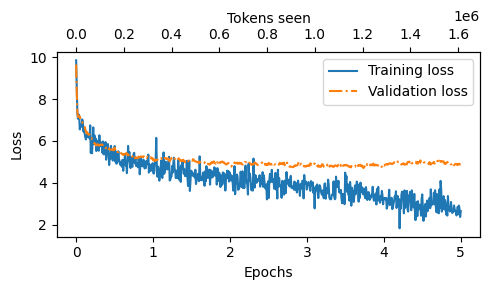

In [34]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

### STEP 13: IMPLEMENTING TEMPERATURE SCALING AND TOP-K SAMPLING

In [35]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [36]:
import torch

# Set random seed for reproducibility
torch.manual_seed(123)

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to the device
model = model.to(device)

# Prepare token_ids
token_ids = text_to_token_ids("Every effort moves you", tokenizer)
token_ids = token_ids.to(device)  # Move token_ids to the correct device

# Generate text with specific parameters
token_ids = generate(
    model=model,
    idx=token_ids,  # Ensure token_ids are on the correct device
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

# Convert token_ids back to text and print
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you if the previous sûtra was lost before as if I could only as


## EXPERIMENT 1 — Phase 1: Learning Rate Sweep at 10 Epochs

We train the model with 4 different learning rates (1e-4, 5e-4, 1e-3, 1e-2) for 10 epochs each to identify which learning rates are viable before doing a full epoch sweep in Phase 2.

In [37]:
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ── Phase 1: LR sweep at 10 epochs ──────────────────────────────────────────
learning_rates = [1e-4, 5e-4, 1e-3, 1e-2]
NUM_EPOCHS_PHASE1 = 10
start_context = "There are four collections or Sa@mhitâs"

phase1_results = {}   # {lr: {"train": [...], "val": [...], "tokens": [...]}}

for lr in learning_rates:
    print(f"\n{'='*60}")
    print(f"Training with lr={lr:.0e}, epochs={NUM_EPOCHS_PHASE1}")
    print(f"{'='*60}")

    torch.manual_seed(123)
    model_exp = GPTModel(GPT_CONFIG_124M)
    model_exp.to(device)
    optimizer_exp = torch.optim.AdamW(model_exp.parameters(), lr=lr, weight_decay=0.1)

    start = time.time()
    train_losses, val_losses, tokens_seen = train_model_simple(
        model_exp, train_loader, val_loader, optimizer_exp, device,
        num_epochs=NUM_EPOCHS_PHASE1,
        eval_freq=5,
        eval_iter=1,
        start_context=start_context,
        tokenizer=tokenizer
    )
    elapsed = (time.time() - start) / 60
    print(f"Finished lr={lr:.0e} in {elapsed:.2f} min | "
          f"Final train loss: {train_losses[-1]:.3f} | "
          f"Final val loss:   {val_losses[-1]:.3f}")

    phase1_results[lr] = {
        "train": train_losses,
        "val":   val_losses,
        "tokens": tokens_seen
    }

print("\n✅ Phase 1 complete.")


Training with lr=1e-04, epochs=10
Ep 1 (Step 000000): Train loss 10.516, Val loss 10.448
Ep 1 (Step 000005): Train loss 9.446, Val loss 9.139
Ep 1 (Step 000010): Train loss 8.791, Val loss 8.715
Ep 1 (Step 000015): Train loss 8.604, Val loss 8.362
Ep 1 (Step 000020): Train loss 8.381, Val loss 8.044
Ep 1 (Step 000025): Train loss 7.937, Val loss 7.740
Ep 1 (Step 000030): Train loss 7.286, Val loss 7.497
Ep 1 (Step 000035): Train loss 7.209, Val loss 7.315
Ep 1 (Step 000040): Train loss 7.056, Val loss 7.129
Ep 1 (Step 000045): Train loss 6.908, Val loss 7.007
Ep 1 (Step 000050): Train loss 7.105, Val loss 6.982
Ep 1 (Step 000055): Train loss 7.016, Val loss 6.908
Ep 1 (Step 000060): Train loss 6.610, Val loss 6.841
Ep 1 (Step 000065): Train loss 6.785, Val loss 6.806
Ep 1 (Step 000070): Train loss 6.564, Val loss 6.753
Ep 1 (Step 000075): Train loss 6.354, Val loss 6.699
Ep 1 (Step 000080): Train loss 6.244, Val loss 6.659
Ep 1 (Step 000085): Train loss 6.262, Val loss 6.546
Ep 1 (Ste

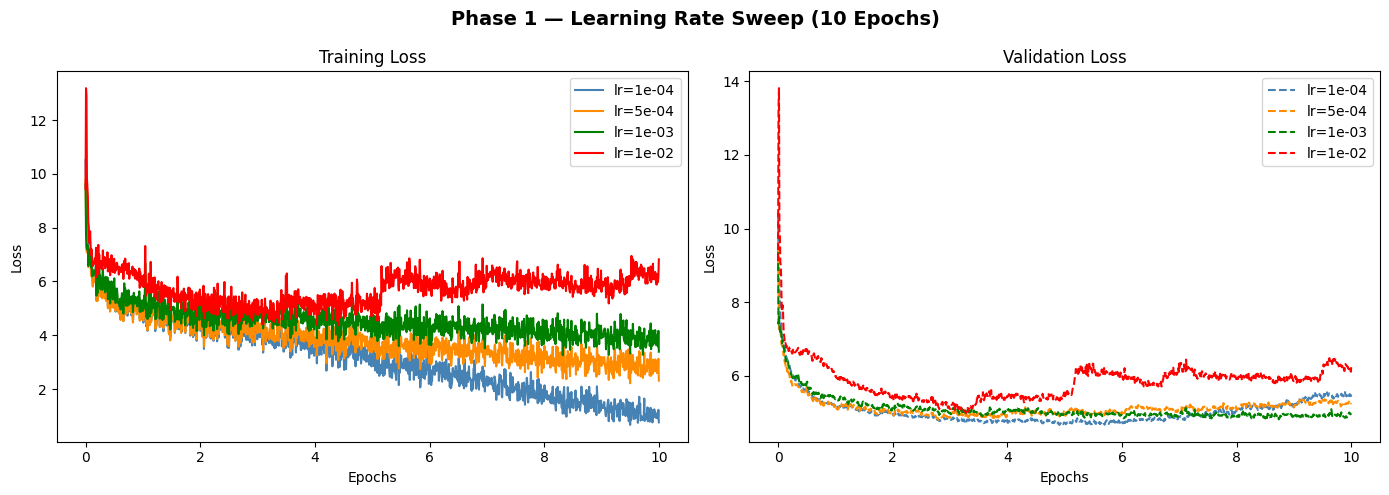


Phase 1 Summary (Final losses after 10 epochs):
LR             Train Loss     Val Loss
--------------------------------------
1e-04              0.7606       5.4397
5e-04              2.3120       5.2597
1e-03              3.3890       4.9414
1e-02              6.8244       6.3001

→ Select the top 2 LRs with lowest validation loss for Phase 2.


In [38]:
# ── Phase 1: Plot all LR curves side by side ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 1 — Learning Rate Sweep (10 Epochs)", fontsize=14, fontweight="bold")

colors = {1e-4: "steelblue", 5e-4: "darkorange", 1e-3: "green", 1e-2: "red"}

for lr, res in phase1_results.items():
    epochs_x = torch.linspace(0, NUM_EPOCHS_PHASE1, len(res["train"])).tolist()
    label = f"lr={lr:.0e}"
    axes[0].plot(epochs_x, res["train"], color=colors[lr], label=label)
    axes[1].plot(epochs_x, res["val"],   color=colors[lr], label=label, linestyle="--")

for ax, title in zip(axes, ["Training Loss", "Validation Loss"]):
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("phase1_lr_sweep.pdf")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\nPhase 1 Summary (Final losses after 10 epochs):")
print(f"{'LR':<12} {'Train Loss':>12} {'Val Loss':>12}")
print("-" * 38)
for lr, res in sorted(phase1_results.items()):
    print(f"{lr:<12.0e} {res['train'][-1]:>12.4f} {res['val'][-1]:>12.4f}")

print("\n→ Select the top 2 LRs with lowest validation loss for Phase 2.")